# Quickstart: your first bootstrap

`tsbootstrap` resamples time series. The whole public API is one function,
`bootstrap`, configured with a typed method specification. This notebook runs a
block bootstrap, reads its results, and asks `diagnose` which method fits the data.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## A small series

We use a stationary AR(1) process so the dependence structure is known.

In [2]:
import numpy as np

rng = np.random.default_rng(0)
n, phi = 200, 0.6
x = np.zeros(n)
for t in range(1, n):
    x[t] = phi * x[t - 1] + rng.standard_normal()
x[:5]

array([ 0.        ,  0.12573022, -0.05666673,  0.60642261,  0.46875368])

## One bootstrap call

`MovingBlock(block_length="auto")` picks the block length with the Politis-White
rule. The result carries the samples plus provenance and out-of-bag primitives.

In [3]:
from tsbootstrap import bootstrap, MovingBlock

result = bootstrap(
    x, method=MovingBlock(block_length="auto"), n_bootstraps=200, random_state=0
)
samples = result.values()
samples.shape  # (n_bootstraps, n)

(200, 200)

## Out-of-bag mask

Observation-resampling methods record which points were left out of each replicate.
This out-of-bag structure is what the EnbPI uncertainty layer builds on.

In [4]:
mask = result.get_oob_mask()
mask.shape, round(float(mask.mean()), 3)  # ~0.37 of points are OOB per replicate

((200, 200), 0.361)

## Which method should I use?

`diagnose` inspects the series (serial dependence, stationarity) and recommends
method specifications. It is a heuristic starting point, not a guarantee; the
decision-guide tutorial shows when each method is the right choice.

In [5]:
from tsbootstrap import diagnose

diagnose(x).recommended_methods

('StationaryBlock', 'MovingBlock', 'SieveAR')

## Visualizing replicates

Each replicate is a new series that preserves the local dependence of the original.

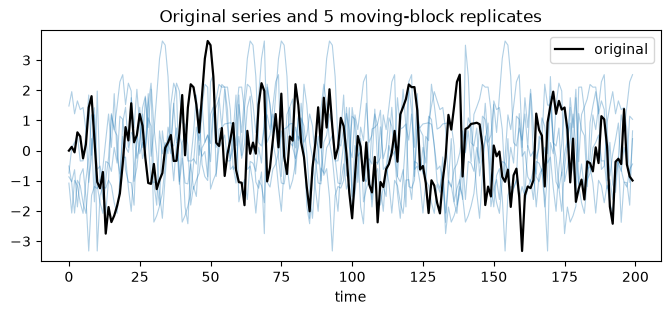

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
for i in range(5):
    ax.plot(samples[i], color="tab:blue", alpha=0.35, lw=0.8)
ax.plot(x, color="black", lw=1.6, label="original")
ax.set_title("Original series and 5 moving-block replicates")
ax.set_xlabel("time")
ax.legend()
plt.show()